In [31]:
from google.colab import files
uploaded = files.upload()

Saving car1.zip to car1 (3).zip
Saving car2.zip to car2 (3).zip
Saving car3.zip to car3 (3).zip


In [32]:
import zipfile
import os

os.makedirs('dataset/car1', exist_ok=True)
os.makedirs('dataset/car2', exist_ok=True)
os.makedirs('dataset/car3', exist_ok=True)

with zipfile.ZipFile('car1.zip', 'r') as z:
    z.extractall('dataset/car1')

with zipfile.ZipFile('car2.zip', 'r') as z:
    z.extractall('dataset/car2')

with zipfile.ZipFile('car3.zip', 'r') as z:
    z.extractall('dataset/car3')

for car in ['car1', 'car2', 'car3']:
    print(f"{car}: {len(os.listdir(f'dataset/{car}'))} images")

car1: 21 images
car2: 22 images
car3: 20 images


In [33]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from PIL import Image
from sklearn.model_selection import train_test_split

dataset_path = 'dataset'
class_names = ['car1', 'car2', 'car3']



In [34]:
X = [] #images
y = [] #labels

for label, class_name in enumerate(class_names):
    class_folder = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)
        img = Image.open(img_path).convert('RGB')
        img = img.resize((32, 32))
        img_array = np.array(img)
        X.append(img_array)
        y.append(label)

X = np.array(X)
y = np.array(y)

In [35]:
X = X/255.0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = cnn.fit(X_train, y_train, epochs=10, batch_size = 32, validation_data=(X_test, y_test))

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 468ms/step - accuracy: 0.1600 - loss: 1.1244 - val_accuracy: 0.2308 - val_loss: 1.1109
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.4400 - loss: 1.0713 - val_accuracy: 0.4615 - val_loss: 1.0815
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7200 - loss: 1.0639 - val_accuracy: 0.4615 - val_loss: 1.0702
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.6800 - loss: 1.0432 - val_accuracy: 0.3077 - val_loss: 1.0702
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5400 - loss: 1.0146 - val_accuracy: 0.3077 - val_loss: 1.0571
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5400 - loss: 0.9814 - val_accuracy: 0.4615 - val_loss: 1.0361
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6200 - loss: 0.9261 - val_accuracy: 0.4615 - val_loss: 0.9928
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.7200 - loss: 0.8734 - val_accuracy: 0.4615 - val_loss: 0.

In [38]:
from google.colab import files
from PIL import Image
import numpy as np

class_names = ['Opel Astra', 'Ford Escort', 'Ford F350']

print("Upload an image to identify:")
pred_upload = files.upload()

pred_filename = list(pred_upload.keys())[0]
pred_img = Image.open(pred_filename).convert('RGB')
pred_img = pred_img.resize((32, 32))
pred_array = np.array(pred_img) / 255.0
pred_array = pred_array.reshape(1, 32, 32, 3)

prediction = cnn.predict(pred_array)
predicted_class = class_names[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print(f"\nCar: {predicted_class} (Confidence: {confidence:.2f}%)")

Upload an image to identify:


Saving car2.png to car2 (2).png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step

Car: Ford Escort (Confidence: 74.54%)


(0.0, 1.0)

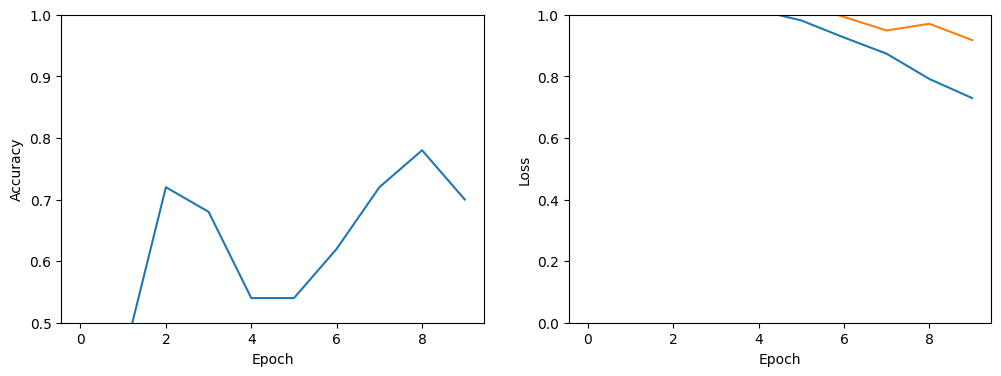

In [39]:
plt.figure(figsize=(12, 4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.ylim([0, 1])